DATASET OVERVIEW

First 5 Rows:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S



Dataset Shape: (891, 12)

Column Names:
['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB

Missing Values:
PassengerId      0
Survived         0
Pclass   

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200



Missing Values After Cleaning:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


/tmp/ipykernel_5074/2990286747.py:32: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Age"].fillna(df["Age"].median(), inplace=True)
/tmp/ipykernel_5074/2990286747.py:33: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', 

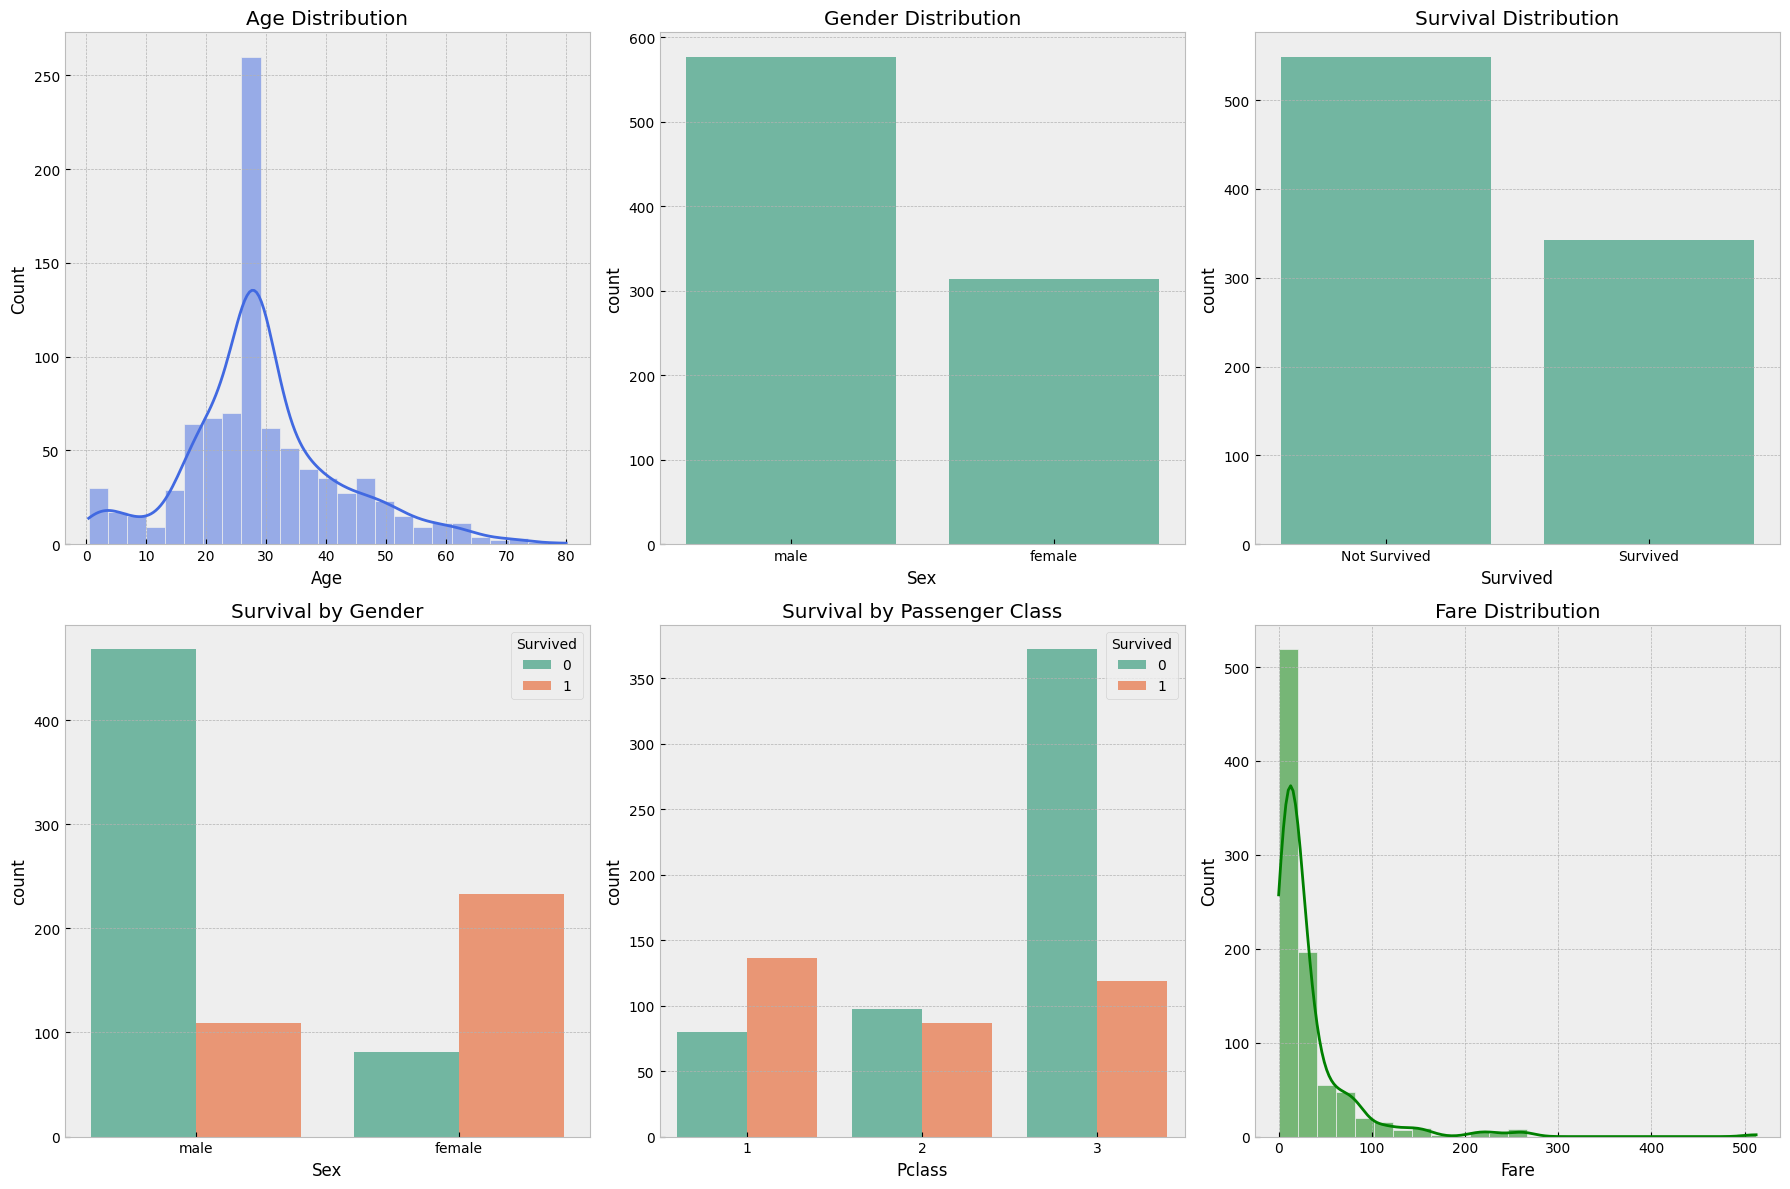

/tmp/ipykernel_5074/2990286747.py:66: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0].set_xticklabels(["Not Survived","Survived"])
/tmp/ipykernel_5074/2990286747.py:70: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[1].set_xticklabels(["Not Survived","Survived"])


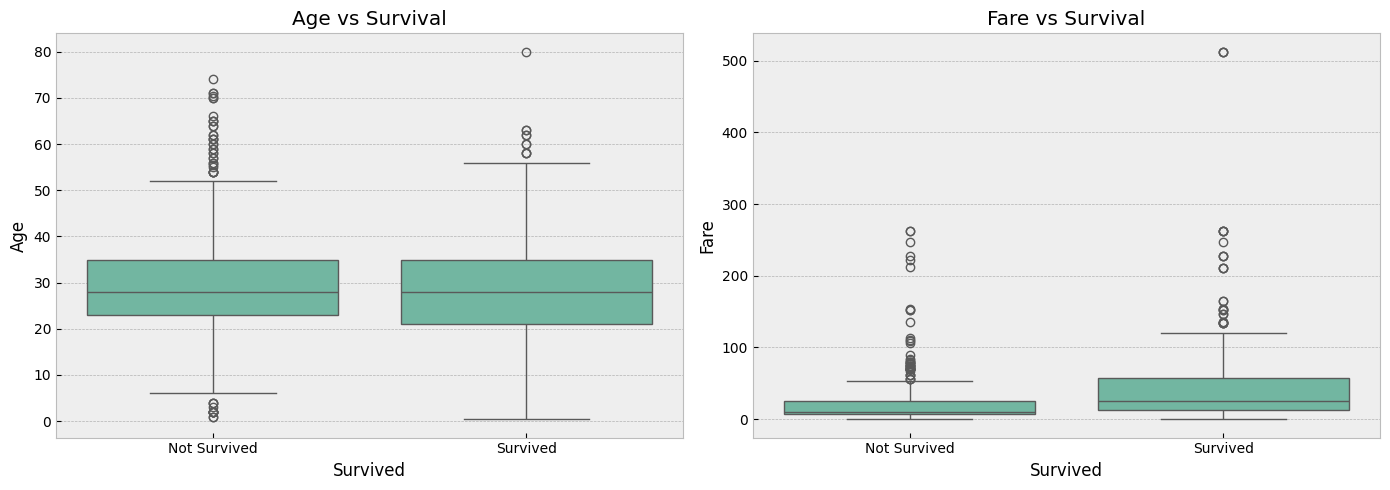

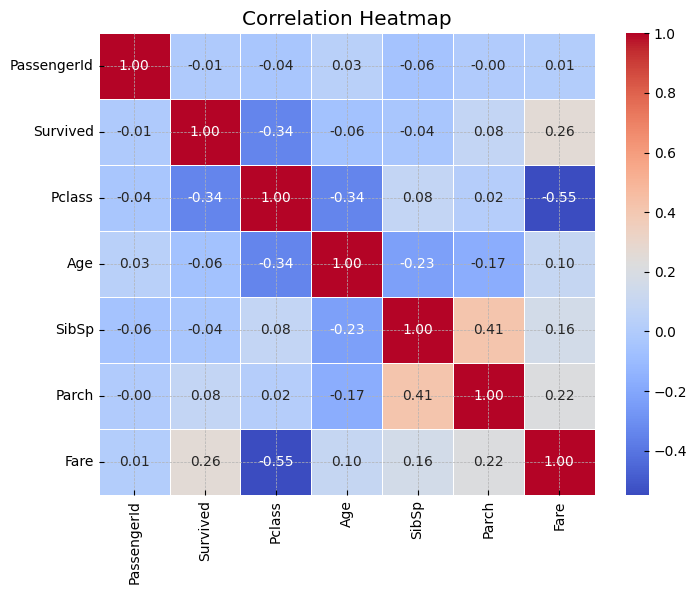

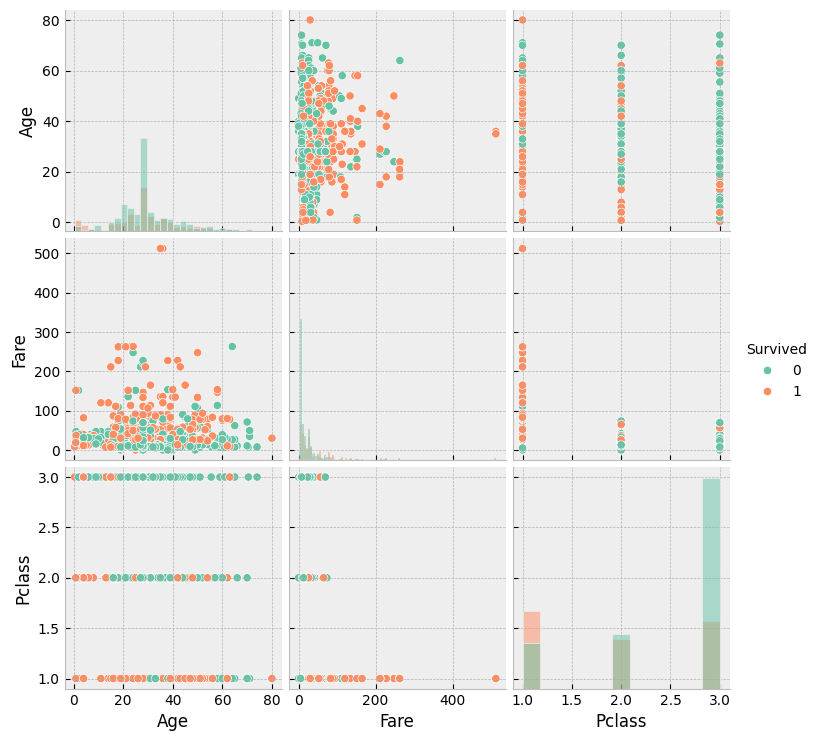


KEY OBSERVATIONS
• Most passengers were between 20 and 40 years old.
• Male passengers were more numerous than female passengers.
• Female passengers had a higher survival rate.
• First-class passengers had better survival chances.
• Higher ticket fares were generally associated with higher survival.
• Age showed only a weak relationship with survival.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('bmh')
sns.set_palette("Set2")

df = pd.read_csv("Titanic-Dataset.csv")

print("="*60)
print("DATASET OVERVIEW")
print("="*60)

print("\nFirst 5 Rows:")
display(df.head())

print("\nDataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nDataset Information:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

print("\nStatistical Summary:")
display(df.describe())

df["Age"].fillna(df["Age"].median(), inplace=True)
df["Embarked"].fillna(df["Embarked"].mode()[0], inplace=True)
df.drop(columns=["Cabin"], inplace=True)

print("\nMissing Values After Cleaning:")
print(df.isnull().sum())

fig, ax = plt.subplots(2, 3, figsize=(18, 12))

sns.histplot(df["Age"], bins=25, kde=True, color="royalblue", ax=ax[0,0])
ax[0,0].set_title("Age Distribution")

sns.countplot(data=df, x="Sex", ax=ax[0,1])
ax[0,1].set_title("Gender Distribution")

sns.countplot(data=df, x="Survived", ax=ax[0,2])
ax[0,2].set_xticklabels(["Not Survived","Survived"])
ax[0,2].set_title("Survival Distribution")

sns.countplot(data=df, x="Sex", hue="Survived", ax=ax[1,0])
ax[1,0].set_title("Survival by Gender")

sns.countplot(data=df, x="Pclass", hue="Survived", ax=ax[1,1])
ax[1,1].set_title("Survival by Passenger Class")

sns.histplot(df["Fare"], bins=25, kde=True, color="green", ax=ax[1,2])
ax[1,2].set_title("Fare Distribution")

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df, x="Survived", y="Age", ax=ax[0])
ax[0].set_xticklabels(["Not Survived","Survived"])
ax[0].set_title("Age vs Survival")

sns.boxplot(data=df, x="Survived", y="Fare", ax=ax[1])
ax[1].set_xticklabels(["Not Survived","Survived"])
ax[1].set_title("Fare vs Survival")

plt.tight_layout()
plt.show()

numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(8,6))
sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm",
    linewidths=0.5,
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

sns.pairplot(
    df[["Age","Fare","Pclass","Survived"]],
    hue="Survived",
    diag_kind="hist"
)

plt.show()

print("\n" + "="*60)
print("KEY OBSERVATIONS")
print("="*60)

print("• Most passengers were between 20 and 40 years old.")
print("• Male passengers were more numerous than female passengers.")
print("• Female passengers had a higher survival rate.")
print("• First-class passengers had better survival chances.")
print("• Higher ticket fares were generally associated with higher survival.")
print("• Age showed only a weak relationship with survival.")